In [68]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

import joblib
import optuna
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv("/kaggle/input/dd-data/hofitzer_data.csv")
data

,Unnamed: 0,person,car,bus,truck,target_status
0,0,0,0,0,0,no_target
1,1,0,0,0,1,undecided
2,2,0,0,1,0,undecided
3,3,0,0,1,1,found
4,4,0,1,0,0,undecided
...,...,...,...,...,...,...
1019,1019,1,0,1,1,found
1020,1020,1,1,0,0,found
1021,1021,1,1,0,1,found
1022,1022,1,1,1,0,found


In [3]:
data.columns

Index(['Unnamed: 0', 'person', 'car', 'bus', 'truck', 'target_status'], dtype='object')

In [4]:
data = data.drop("Unnamed: 0", axis="columns")

In [5]:
data

,person,car,bus,truck,target_status
0,0,0,0,0,no_target
1,0,0,0,1,undecided
2,0,0,1,0,undecided
3,0,0,1,1,found
4,0,1,0,0,undecided
...,...,...,...,...,...
1019,1,0,1,1,found
1020,1,1,0,0,found
1021,1,1,0,1,found
1022,1,1,1,0,found


In [6]:
data.isnull().sum()

person           0
car              0
bus              0
truck            0
target_status    0
dtype: int64

In [7]:
data["target_status"].unique()

array(['no_target', 'undecided', 'found'], dtype=object)

In [8]:
data

,person,car,bus,truck,target_status
0,0,0,0,0,no_target
1,0,0,0,1,undecided
2,0,0,1,0,undecided
3,0,0,1,1,found
4,0,1,0,0,undecided
...,...,...,...,...,...
1019,1,0,1,1,found
1020,1,1,0,0,found
1021,1,1,0,1,found
1022,1,1,1,0,found


In [9]:
data["target_status"].unique()

array(['no_target', 'undecided', 'found'], dtype=object)

In [10]:
data["target_status"].replace({"no_target": 0, "undecided": 1, "found":2}, inplace=True)

<ipython-input-10-2b8fa4a28694>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["target_status"].replace({"no_target": 0, "undecided": 1, "found":2}, inplace=True)
<ipython-input-10-2b8fa4a28694>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["target_status"].replace({"no_target": 0, "u

In [11]:
data

,person,car,bus,truck,target_status
0,0,0,0,0,0
1,0,0,0,1,1
2,0,0,1,0,1
3,0,0,1,1,2
4,0,1,0,0,1
...,...,...,...,...,...
1019,1,0,1,1,2
1020,1,1,0,0,2
1021,1,1,0,1,2
1022,1,1,1,0,2


In [12]:
corr = data.corr(method="pearson")
corr


,person,car,bus,truck,target_status
person,1.000000e+00,-1.734723e-18,2.602085e-18,-3.686287e-18,0.536056
car,-1.734723e-18,1.000000e+00,-1.301043e-18,-4.336809e-19,0.321634
bus,2.602085e-18,-1.301043e-18,1.000000e+00,-8.673617e-19,0.321634
truck,-3.686287e-18,-4.336809e-19,-8.673617e-19,1.000000e+00,0.321634
target_status,5.360563e-01,3.216338e-01,3.216338e-01,3.216338e-01,1.000000


([<matplotlib.axis.YTick at 0x7a62cfe6f520>,
 [Text(0, 0, 'person'),
  Text(0, 1, 'car'),
  Text(0, 2, 'bus'),
  Text(0, 3, 'truck'),
  Text(0, 4, 'target_status')])

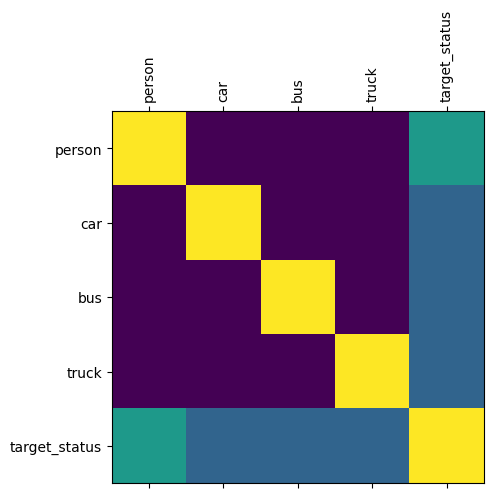

In [13]:
plt.matshow(corr)

plt.xticks(range(len(data.columns)), data.columns, rotation=90)
plt.yticks(range(len(data.columns)), data.columns)

In [60]:
x = data.drop("target_status", axis="columns")
y = data["target_status"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [51]:
def optimization(trial):
    x = data.drop("target_status", axis="columns")
    y = data["target_status"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    model_name = trial.suggest_categorical("model_name", ["SVC", "KNN", "RFClassifier", "DTClassifier"])

    if model_name == "SVC":
        C = trial.suggest_int("C", 1, 4)
        degree = trial.suggest_int("degree", 2, 5)
        max_iter = trial.suggest_int("max_iter", 10, 50)

        cls = SVC(
            C=C,
            degree=degree,
            max_iter=max_iter
        )

    elif model_name == "KNN":
        n_neighbors = trial.suggest_int("n_neighbors", 3, 9)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        algorithm = trial.suggest_categorical("algorithm", ['auto', 'ball_tree', 'brute'])

        cls = KNeighborsClassifier(
            n_neighbors = n_neighbors,
            weights = weights,
            algorithm = algorithm
        )

    elif model_name == "RFClassifier":
        n_estimators = trial.suggest_int("n_estimators", 50, 150)
        max_depth = trial.suggest_int("max_depth", 1, 10)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        cls = RandomForestClassifier(
            n_estimators = n_estimators,
            max_depth = max_depth,
            max_features = max_features,
            criterion = criterion
        )

    elif model_name == "DTClassifier":
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
        splitter = trial.suggest_categorical("splitter", ["best", "random"])
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

        cls = DecisionTreeClassifier(
            criterion = criterion,
            splitter = splitter,
            max_features = max_features
        )


    cls.fit(x_train, y_train)
    y_preds = cls.predict(x_test)
    accuracy = accuracy_score(y_test, y_preds)   
    return accuracy
        

In [52]:
study = optuna.create_study(direction="maximize")
study.optimize(optimization, n_trials=30)

[I 2025-03-17 11:54:05,124] A new study created in memory with name: no-name-2e0df4bf-a2ac-4fa0-977b-7a5027021164
[I 2025-03-17 11:54:05,138] Trial 0 finished with value: 1.0 and parameters: {'model_name': 'KNN', 'n_neighbors': 9, 'weights': 'distance', 'algorithm': 'auto'}. Best is trial 0 with value: 1.0.
[I 2025-03-17 11:54:05,149] Trial 1 finished with value: 1.0 and parameters: {'model_name': 'SVC', 'C': 3, 'degree': 5, 'max_iter': 25}. Best is trial 0 with value: 1.0.
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=17).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
[I 2025-03-17 11:54:05,159] Trial 2 finished with value: 1.0 and parameters: {'model_name': 'SVC', 'C': 2, 'degree': 4, 'max_iter': 17}. Best is trial 0 with value: 1.0.
[I 2025-03-17 11:54:05,167] Trial 3 finished with value: 1.0 and parameters: {'model_name': 'DTClassifier', 'criterion': 'log_loss', 'spl

In [54]:
print("Best trial: ")
trial = study.best_trial
print(f"Accuracy: {trial.value}")
print(f"Best hyperparameters: {trial.params}")

Best trial: 
Accuracy: 1.0
Best hyperparameters: {'model_name': 'KNN', 'n_neighbors': 9, 'weights': 'distance', 'algorithm': 'auto'}


In [61]:
best_params = trial.params

best_model = KNeighborsClassifier(
    n_neighbors = best_params["n_neighbors"],
    weights = best_params["weights"],
    algorithm = best_params["algorithm"]

)

best_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=9, weights='distance')

In [62]:
best_model.score(x_test, y_test)

1.0

In [65]:
preds = best_model.predict(x_test)

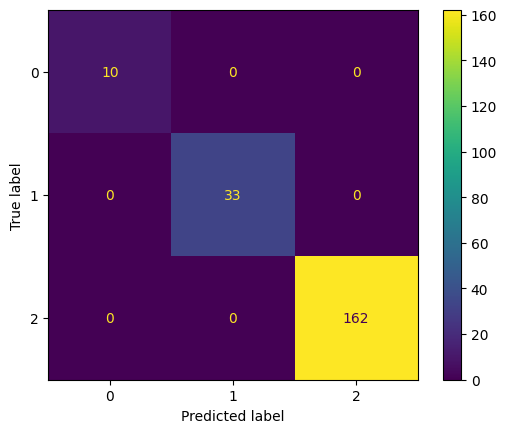

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, preds, labels=[0, 1, 2])

In [69]:
joblib.dump(best_model, "decision_maker.pkl")

['decision_maker.pkl']

In [70]:
t_model = best_model

t_model = joblib.load("/kaggle/working/decision_maker.pkl")
t_model.score(x_test, y_test)

1.0